# インターオペラビリティ

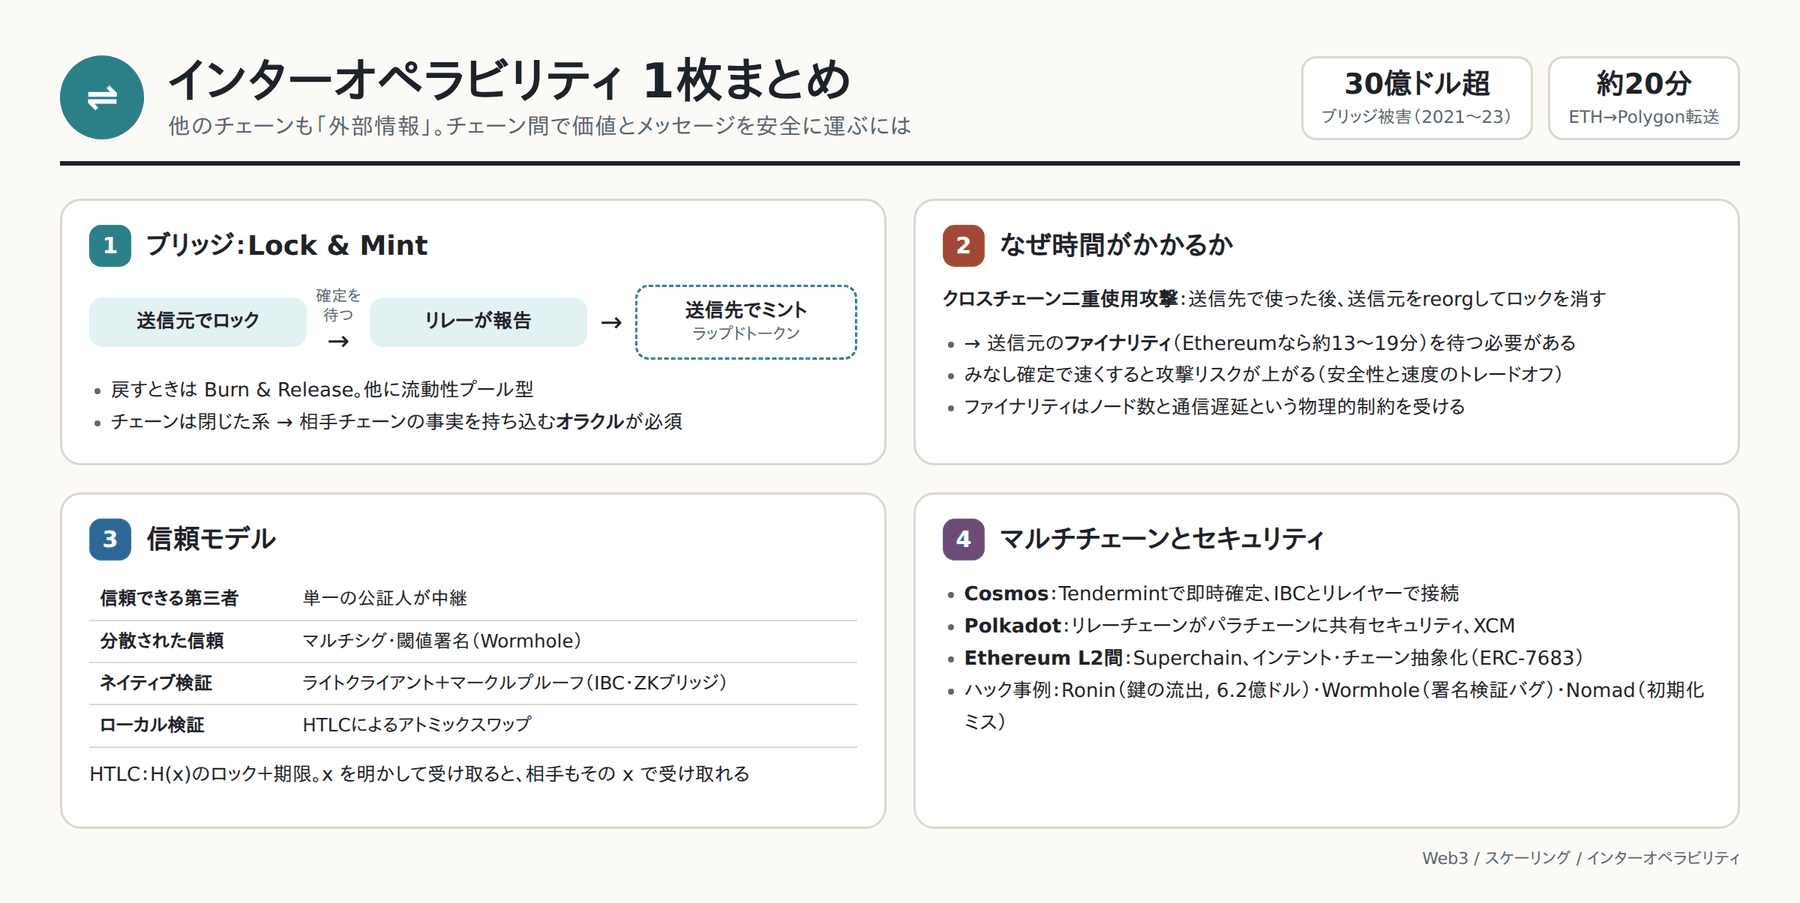

## 相互運用性とは

ソフトウェア工学における **相互運用性（interoperability）** は、「言語、インターフェース、実行環境の違いにもかかわらず、2つ以上のソフトウェアの構成要素が協調して動作できる能力」（Wegner, 1996）と定義される。

ブロックチェーンの文脈では、**複数の異なるブロックチェーンの間で、価値（暗号資産）の移転・交換やデータの読み書きができる性質** を指し、クロスチェーン相互運用性とも呼ばれる。

実現方法は大きく2つある。

- **橋渡し（ブリッジ）による翻訳**：既存の異なるチェーンの間をつなぐ（クロスチェーン）
- **標準化による統一**：はじめから相互運用を前提にした共通の規格の上に複数のチェーンを作る（マルチチェーン）

### 相互運用の様式

| 様式 | 例 |
| --- | --- |
| トークンの転送 | Ethereum上のETHを、Arbitrum上で使えるようにする |
| トークンの交換 | 自分のETHを、誰かのBTCと交換する |
| データ（メッセージ）の転送 | あるチェーンのコントラクトから、別のチェーンのコントラクトの関数を呼ぶ |

## なぜ難しいのか：オラクル問題

「スマートコントラクトを使えば簡単では？」と思うかもしれないが、ブロックチェーンは基本的に **閉じた系** である。

- チェーン内部の取引の正当性は検証できる
- チェーン外部の情報（株価、天気、センサーの値など）を直接知る手段がなく、届いた情報の正しさも検証できない

正しい外部情報を安全にブロックチェーンに取り込むことの難しさを **オラクル問題** と呼ぶ。そして、**他のブロックチェーンの状態も外部情報の1つ** である。チェーンAのコントラクトは、チェーンBで「ロックされた」という事実を自分では確認できない。チェーン間でやりとりするには、相手チェーンの情報を安全に持ち込む仕組み（オラクル）が不可欠になる。

## ブリッジ

### Lock & Mint

最も基本的なブリッジは **Lock & Mint / Burn & Release** 方式。

```mermaid
sequenceDiagram
    participant U as ユーザー
    participant S as 送信元チェーン<br/>（ブリッジコントラクト）
    participant R as リレー
    participant T as 送信先チェーン<br/>（ブリッジコントラクト）
    U->>S: トークンをロック
    S-->>R: Lockイベント
    R->>R: 送信元チェーンでの確定を待つ
    R->>T: ロックされたことを報告
    T->>U: ラップドトークンをミント
    Note over U,T: 戻すとき：送信先でバーン → 送信元でリリース
```

送信先チェーンで発行されるのは、ロックされた元のトークンを裏付けとする **ラップドトークン**（例：Ethereum上のWBTCはBitcoinのBTCを裏付けとする）。ラップドトークンの価値は、ブリッジが正しく動き続けることに依存している。

他に、両方のチェーンにあらかじめ流動性プールを用意しておき、送信元で預けた分を送信先のプールから払い出す **流動性ネットワーク型** のブリッジもある。

### なぜ時間がかかるのか：クロスチェーン二重使用

ブリッジでの転送には、ブロック時間よりずっと長い時間がかかることが多い。例えばEthereum（ブロック時間12秒）からPolygon PoS（数秒）への転送は20分程度かかる。

理由は、送信元チェーンの **ファイナリティ** を待つ必要があるからである。もし送信元でロックが確定する前に送信先でミントしてしまうと、

1. 送信元でトークンをロックする
2. 送信先でラップドトークンを受け取って使う
3. 送信元のチェーンを分岐（reorg）させ、ロックのトランザクションをなかったことにする

という **クロスチェーン二重使用攻撃** が可能になり、送信元のトークンと送信先のトークンを両方使えてしまう。Ethereumのファイナリティは約2〜3エポック（13〜19分）なので、それを待ってからミントする。

ファイナリティを待たずに「みなし確定」で転送すれば速くなるが、その分攻撃されるリスクが高まる。**安全性と速度のトレードオフ** がある。

ファイナリティ時間は、合意のために全バリデータ間で行う通信の時間で決まり、ノード数や通信速度という物理的な制約を受けるため、劇的に短縮するのは難しい。

## ブリッジの信頼モデル

「相手チェーンで何が起きたか」を誰がどうやって保証するかで、ブリッジは次のように分類できる。

| 信頼モデル | 仕組み | 例 | 特徴 |
| --- | --- | --- | --- |
| 信頼できる第三者 | 単一の運営者（公証人）が中継する | 中央集権型取引所、初期のWBTC | 単純だが、運営者を信頼する必要がある |
| 分散された信頼 | 複数のバリデータの多数決（マルチシグ、閾値署名）で中継する | Wormhole（Guardian）, Multichain | 過半数の鍵が奪われると破綻する |
| ネイティブな検証 | 相手チェーンのライトクライアントをコントラクト上で動かし、ブロックヘッダーとマークルプルーフで直接検証する | Cosmos IBC, ZKブリッジ, ロールアップの公式ブリッジ | 相手チェーン以上の信頼を必要としないが、実装が難しくコストが高い |
| ローカルな検証 | 取引の当事者同士が、ハッシュロックとタイムロックで直接やりとりする | HTLCによるアトミックスワップ | 第三者を必要としないが、交換相手を見つける必要がある |

### ライトクライアントによる検証

ライトクライアントは、相手チェーンのブロックヘッダー（とその正当性の証拠、例えばバリデータの署名）を追跡する。あるトランザクションがブロックに含まれていることは、そのトランザクションのマークルプルーフとブロックヘッダーのルートを突き合わせれば確認できる（→[データ構造](../blockchain/data_structure.ipynb)）。

ライトクライアントの検証をコントラクト上で行うのはgasがかかりすぎることがあるため、検証をオフチェーンで行い、その正しさのゼロ知識証明だけをコントラクトで検証する **ZKブリッジ** も研究・実用化されている。

## HTLCによるアトミックスワップ

**HTLC（Hashed Timelock Contract）** は、次の2つの条件を組み合わせた支払い。

- **ハッシュロック**：ハッシュ値 $y = H(x)$ に対して、その原像 $x$ を示した人が受け取れる
- **タイムロック**：期限までに受け取られなければ、送り主に返金される

これを使うと、AliceのBTCとBobのETHを、第三者なしで **アトミックに**（両方成立するか、両方成立しないかのどちらか）交換できる。

1. Aliceが秘密 $x$ を作り、$y = H(x)$ を計算する
2. AliceがBitcoin上で「$x$ を示せばBobが受け取れる。期限 $T_A$ を過ぎたらAliceに返金」というHTLCにBTCをロックする
3. Bobがそれを確認し、Ethereum上で「$x$ を示せばAliceが受け取れる。期限 $T_B$ を過ぎたらBobに返金」というHTLCにETHをロックする（$T_B < T_A$）
4. AliceがEthereumのHTLCに $x$ を示してETHを受け取る。このとき $x$ がチェーン上で公開される
5. Bobは公開された $x$ を使って、BitcoinのHTLCからBTCを受け取る

$T_B < T_A$ にしておくのは、Aliceが期限ぎりぎりで $x$ を明かしたときでも、Bobが $x$ を使って受け取る時間を確保するため。Bobは $x$ が公開されるのを監視し続ける必要がある。

In [1]:
import hashlib
import secrets
from dataclasses import dataclass


@dataclass
class HTLC:
    sender: str
    recipient: str
    amount: float
    hashlock: bytes
    timelock: int
    claimed_by: str | None = None
    preimage: bytes | None = None  # 受け取り時に公開される

    def claim(self, who: str, preimage: bytes, now: int) -> bool:
        if who == self.recipient and now < self.timelock and self.claimed_by is None and hashlib.sha256(preimage).digest() == self.hashlock:
            self.claimed_by, self.preimage = who, preimage
            return True
        return False

    def refund(self, now: int) -> bool:
        if now >= self.timelock and self.claimed_by is None:
            self.claimed_by = self.sender
            return True
        return False


x = secrets.token_bytes(32)  # Aliceだけが知る秘密
y = hashlib.sha256(x).digest()

btc_htlc = HTLC("Alice", "Bob", 1.0, y, timelock=48)  # Bitcoin上
eth_htlc = HTLC("Bob", "Alice", 30.0, y, timelock=24)  # Ethereum上（期限が短い）

print("BobがAliceより先にETHを取ろうとする:", eth_htlc.claim("Bob", b"guess", now=1))
print("AliceがETHを受け取る:", eth_htlc.claim("Alice", x, now=10))
print("Bobが公開された原像でBTCを受け取る:", btc_htlc.claim("Bob", eth_htlc.preimage, now=11))
print("結果:", f"BTC→{btc_htlc.claimed_by}, ETH→{eth_htlc.claimed_by}")

BobがAliceより先にETHを取ろうとする: False
AliceがETHを受け取る: True
Bobが公開された原像でBTCを受け取る: True
結果: BTC→Bob, ETH→Alice


## マルチチェーン

はじめから複数のチェーンの相互運用を前提に設計されたエコシステムを **マルチチェーン** と呼ぶ。

### Cosmos

**Cosmos** は、独立したチェーン（アプリチェーン）を簡単に作れるフレームワーク（Cosmos SDK）と、チェーン間の通信規格 **IBC（Inter-Blockchain Communication）** を中心とするエコシステム。

- 各チェーンは **Tendermint（CometBFT）** で合意し、ブロック時間 = ファイナリティ時間（即時確定）
- **リレイヤー** が互いのチェーンを監視し、相手チェーンのライトクライアントにヘッダーとプルーフを届ける
- チェーンごとにセキュリティ（バリデータ）は独立している

### Polkadot

**Polkadot** は、中心となる **リレーチェーン** に、**パラチェーン** と呼ばれる複数のチェーンを接続する構成。

- リレーチェーンのバリデータがパラチェーンのブロックも検証する **共有セキュリティ** により、パラチェーンは自前でバリデータを集める必要がない
- チェーン間のメッセージは **XCM / XCMP** で受け渡す
- 合意はBABE（ブロック生成）とGRANDPA（ファイナリティ）の組み合わせで、Ethereumの設計と似ている

### Ethereum L2間の相互運用

Ethereumのエコシステムでは、L2が増えた結果、流動性とユーザーがL2ごとに分断されることが課題になっている。

- **共通の決済層**：ロールアップはどれもEthereum L1を決済層としているので、L1経由なら信頼の追加なしに資産を移せる（ただしOptimistic Rollupからの引き出しは7日かかる）
- **Superchain（OP Stack）** や **Elastic Network（ZK Stack）** など、同じ技術スタックのL2同士を高速に接続する構想
- **インテント**：「チェーンAのUSDCを、チェーンBのETHに替えたい」という目的だけを表明し、具体的な経路はソルバー（専門の業者）が競争して実行する方式。ユーザーにチェーンの違いを意識させない **チェーン抽象化** の手段として注目されている（ERC-7683など）

## ブリッジのセキュリティ

ブリッジは、多額の資産をロックしたコントラクトと、複数のチェーンにまたがる複雑なロジックを持つため、ハッキングの標的になりやすい。2021〜2023年だけで、ブリッジへの攻撃による被害は30億ドルを超える。

| 事件 | 年 | 被害額 | 原因 |
| --- | --- | --- | --- |
| Ronin Bridge | 2022 | 約6.2億ドル | 9つのバリデータ鍵のうち5つが奪われた（ソーシャルエンジニアリング） |
| Wormhole | 2022 | 約3.2億ドル | 署名検証のバグにより、検証を回避してミントされた |
| Nomad | 2022 | 約1.9億ドル | アップグレード時の初期化ミスで、任意のメッセージが有効と判定されるようになった |

被害の原因は大きく、

- 鍵の管理（マルチシグの鍵の流出）
- スマートコントラクトのバグ（検証の不備）
- リレーネットワークの異常（中央集権化、悪意のあるノード）

に分けられる。オラクルを完全になくすことはできない以上、「何を信頼しているのか」を把握して使うことが重要である。

## 参考文献

- Augusto, A. et al. (2024). [SoK: Security and Privacy of Blockchain Interoperability](https://doi.org/10.1109/SP54263.2024.00255). IEEE S&P.
- Ren, K. et al. (2023). [Interoperability in Blockchain: A Survey](https://doi.org/10.1109/TKDE.2023.3275220). IEEE TKDE.
- Xie, T. et al. (2022). [zkBridge: Trustless Cross-chain Bridges Made Practical](https://doi.org/10.1145/3548606.3560652). ACM CCS.
- Belchior, R. et al. (2023). [Do You Need a Distributed Ledger Technology Interoperability Solution?](https://doi.org/10.1145/3564532). Distributed Ledger Technologies.
- [Bridges | ethereum.org](https://ethereum.org/developers/docs/bridges/)
- [IBC Protocol](https://ibcprotocol.dev/)